In [28]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph,START,END
from langchain_core.documents import Document
from pydantic import BaseModel,Field
from typing import List,TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv
from langchain_groq import ChatGroq
import os
import re
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.vectorstores import FAISS
load_dotenv()

True

In [6]:
docs=(
    PyPDFLoader(r"./documents/book1 (1).pdf").load() +
    PyPDFLoader(r"./documents/book2 (1).pdf").load() + 
    PyPDFLoader(r"./documents/book3 (1).pdf").load()
)

In [7]:
len(docs)

2123

In [8]:
chunks=RecursiveCharacterTextSplitter(chunk_size=900,chunk_overlap=150).split_documents(docs)

for d in chunks:
    d.page_content=d.page_content.encode("utf-8","ignore").decode("utf-8","ignore")

In [9]:
len(chunks)

6685

In [10]:
import warnings
warnings.filterwarnings("ignore")

embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

In [11]:
vectorstore=FAISS.from_documents(chunks,embeddings)

In [12]:
retriever=vectorstore.as_retriever(search_type="similarity",search_kwargs={'k':4})

In [20]:
llm=ChatGroq(model="llama-3.3-70b-versatile",api_key=os.getenv("GROQ_API_KEY"))

In [21]:
class State(TypedDict):
    question:str
    docs:List[Document]
    strips:List[str]
    kept_strips:List[str]
    refined_context:str
    answer:str


In [22]:
def retriever_node(state:State)-> State:
    q=state["question"]
    return {"docs":retriever.invoke(q)}

In [29]:
#--------------------------
# SENTENCE-LEVEL DECOMPOSER
#--------------------------
def decompose_to_sentences(text:str)->List[str]:
    text=re.sub(r"\s+"," ",text).strip()
    sentences=re.split(r"(?<=[.!?])\s+",text)
    return [s.strip() for s in sentences if len(s.strip())>20]

#-------------------
# FILTER (LLM JUDGE)
#-------------------
class KeepOrDrop(BaseModel):
    keep: bool = Field(description="true if relevant, false if not. Must be a JSON boolean (true/false), not a string.")

filter_prompt=ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a strict relevance filter.\n"
        "Return keep=true only if the sentence directly helps answer the question.\n"
        "Use ONLY the sentences.Output JSON only."
    ),
    (
        "human",
        "Question: {question}\n\n Sentence: \n {sentence}"
    )
])

filter_chain=filter_prompt | llm.with_structured_output(KeepOrDrop)

#---------------------------------------------
# REFINING (DECOMPOSE -> FILTER -> Recompose)
#---------------------------------------------

def refine_node(state:State)-> State:
    q=state["question"]
    #combined retrieved docs into one context string 
    context="\n\n".join(d.page_content for d in state["docs"]).strip()
    #1)DECOMPOSITION: context ->sentence strips
    strips=decompose_to_sentences(context)
    #2)FILTERING: strips -> keep only the relevant strips
    kept: List[str]=[]
    for s in strips:
        if filter_chain.invoke({"question":q,"sentence":s}).keep:
            kept.append(s)
    
    # 3) RECOMPOSE: glue kept strips back together(internal knowledge)
    refined_context="\n".join(kept).strip()

    return {
        "strips":strips,
        "kept_strips":kept,
        "refined_context":refined_context,
    }


In [30]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate_node(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "refined_context": state['refined_context']})
    return {"answer": out.content}

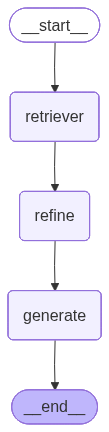

In [31]:
g=StateGraph(State)
g.add_node("retriever",retriever_node)
g.add_node("refine",refine_node)
g.add_node("generate",generate_node)
g.add_edge(START,"retriever")
g.add_edge("retriever","refine")
g.add_edge("refine","generate")
g.add_edge("generate",END)
app=g.compile()
app

In [32]:
res = app.invoke({
    "question": "Explain the bias–variance tradeoff",
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
})
print(res["answer"])

* The bias-variance tradeoff refers to the balance between the error introduced by a model's simplifying assumptions (bias) and the error introduced by the noise in the data (variance).
* Models with low bias tend to have high variance, and models with low variance tend to have high bias.
* The optimal model is the one that minimizes the sum of the squared bias and variance.
* Very flexible models have low bias but high variance, while relatively rigid models have high bias but low variance.
* The goal is to find a model that balances bias and variance to achieve the best predictive capability.


In [33]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

3.2. The Bias-Variance Decomposition 151
Figure 3.6 Plot of squared bias and variance,
together with their sum, correspond-
ing to the results shown in Fig-
ure 3.5. Also shown is the average
test set error for a test data set size
of 1000 points. The minimum value
of (bias)2 + variance occurs around
ln λ = −0.31, which is close to the
value that gives the minimum error
on the test data.
lnλ
−3 −2 −1 0 1 2
0
0.03
0.06
0.09
0.12
0.15
(bias)2
variance
(bias)2 + variance
test error
ﬁt a model with 24 Gaussian basis functions by minimizing the regularized error
function (3.27) to give a prediction function y(l)(x) as shown in Figure 3.5. The
top row corresponds to a large value of the regularization coefﬁcientλ that gives low
variance (because the red curves in the left plot look similar) but high bias (because
****************************************************************************************************
with respect to multiple data sets.
We can also examine the bias-variance trade-

In [34]:
print(res['refined_context'])

The Bias-Variance Decomposition 151 Figure 3.6 Plot of squared bias and variance, together with their sum, correspond- ing to the results shown in Fig- ure 3.5.
The minimum value of (bias)2 + variance occurs around ln λ = −0.31, which is close to the value that gives the minimum error on the test data.
The top row corresponds to a large value of the regularization coefﬁcientλ that gives low variance (because the red curves in the left plot look similar) but high bias (because with respect to multiple data sets.
We can also examine the bias-variance trade-off quantitatively for this example.
The average prediction is estimated from y(x)= 1 L L∑ l=1 y(l)(x) (3.45) and the integrated squared bias and integrated variance are then given by (bias)2 = 1 N N∑ n=1 {y(xn) − h(xn)}2 (3.46) variance = 1 N N∑ n=1 1 L L∑ l=1 { y(l)(xn) − y(xn) }2 (3.47) where the integral over x weighted by the distribution p(x) is approximated by a ﬁnite sum over data points drawn from that distribution.
We see tha

In [ ]:
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

In [35]:

decompose_to_sentences("""A transformer in deep learning is a type of model architecture that is particularly effective for processing sequential data, such as text. It utilizes mechanisms called self-attention and feedforward neural networks to weigh the importance of different parts of the input data, allowing it to capture long-range dependencies and relationships within the data. Unlike traditional recurrent neural networks (RNNs), transformers do not process data sequentially, which enables them to be more parallelizable and efficient in training. This architecture has become foundational in natural language processing tasks and has led to significant advancements in the field.""")

['A transformer in deep learning is a type of model architecture that is particularly effective for processing sequential data, such as text.',
 'It utilizes mechanisms called self-attention and feedforward neural networks to weigh the importance of different parts of the input data, allowing it to capture long-range dependencies and relationships within the data.',
 'Unlike traditional recurrent neural networks (RNNs), transformers do not process data sequentially, which enables them to be more parallelizable and efficient in training.',
 'This architecture has become foundational in natural language processing tasks and has led to significant advancements in the field.']